# Data Understanding: HAM10000, ISIC 2017, dan ISIC 2019

Notebook ini menganalisis karakteristik data mentah, kelengkapan label diagnosis, serta deteksi dan pembersihan duplikasi citra dari 3 dataset utama (HAM10000, ISIC 2017, dan ISIC 2019) sebagai persiapan klasifikasi biner.

## Langkah 1: Setup Library dan Konfigurasi Dataset
Menyiapkan pustaka Python dan mendaftarkan direktori 6 partisi data dari HAM10000, ISIC 2017, dan ISIC 2019.

In [1]:
import os
import glob
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# Deteksi root folder dataset
folder_aktif = os.getcwd()
if os.path.exists(os.path.join(folder_aktif, 'Dataset')):
    ROOT = os.path.join(folder_aktif, 'Dataset')
elif os.path.exists(os.path.join(os.path.dirname(folder_aktif), 'Dataset')):
    ROOT = os.path.join(os.path.dirname(folder_aktif), 'Dataset')
else:
    ROOT = r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"

print(f"Dataset root: {ROOT}")

# Konfigurasi 6 partisi data
SOURCES = {
    'ham10000': {
        'name': 'HAM10000', 'year': '2018', 'split': 'train', 'gt_format': 'ham_dx',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
        'meta_cols': 'lesion_id, dx_type, age, sex, localization'
    },
    'isic_2019_train': {
        'name': 'ISIC 2019 Training', 'year': '2019', 'split': 'train', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
        'meta_cols': 'age_approx, sex, anatom_site_general, lesion_id'
    },
    'isic_2019_test': {
        'name': 'ISIC 2019 Test', 'year': '2019', 'split': 'test', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_GroundTruth.csv'),
        'meta_cols': '-'
    },
    'isic_2017_train': {
        'name': 'ISIC 2017 Training', 'year': '2017', 'split': 'train', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data_metadata.csv'),
        'meta_cols': 'age_approximate, sex'
    },
    'isic_2017_val': {
        'name': 'ISIC 2017 Validation', 'year': '2017', 'split': 'val', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data_metadata.csv'),
        'meta_cols': 'age_approximate, sex'
    },
    'isic_2017_test': {
        'name': 'ISIC 2017 Test', 'year': '2017', 'split': 'test', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data_metadata.csv'),
        'meta_cols': 'age_approximate, sex'
    }
}

print(f"Total partisi sumber: {len(SOURCES)}")

Dataset root: C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset
Total partisi sumber: 6


## Langkah 2: Pemindaian File Gambar Fisik
Memindai file citra (.jpg/.jpeg) dari 6 partisi data untuk menghitung total gambar mentah.

In [2]:
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(d, f)
                        })
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({
                            'image_id': os.path.splitext(f)[0],
                            'source': source,
                            'filepath': os.path.join(root_dir, f)
                        })

df_images = pd.DataFrame(all_images)
print(f"Total gambar fisik terindeks: {len(df_images):,} citra")
print(df_images['source'].value_counts().to_string())

Total gambar fisik terindeks: 46,334 citra
source
isic_2019_train    25331
ham10000           10015
isic_2019_test      8238
isic_2017_train     2000
isic_2017_test       600
isic_2017_val        150


## Langkah 3: Validasi Kelengkapan Data (Citra vs CSV)
Memeriksa kesesuaian antara file gambar fisik di folder dengan baris data pada file CSV ground truth.

In [3]:
ground_truth_dfs = {}
source_label_maps = {}

for source, info in SOURCES.items():
    p = info.get('gt_path')
    fmt = info.get('gt_format')
    if not p or not os.path.exists(p):
        continue
    
    df_gt = pd.read_csv(p)
    id_col = next((c for c in ['image_id', 'image', 'image_name', 'isic_id'] if c in df_gt.columns), df_gt.columns[0])
    df_gt['image_id'] = df_gt[id_col].astype(str).str.replace('.jpg', '', regex=False)
    ground_truth_dfs[source] = df_gt
    
    m = {}
    if fmt == 'ham_dx':
        for _, row in df_gt.iterrows():
            m[row['image_id']] = str(row['dx']).lower()
    elif fmt == '2017':
        for _, row in df_gt.iterrows():
            if row.get('melanoma') == 1.0:
                m[row['image_id']] = 'melanoma'
            elif row.get('seborrheic_keratosis') == 1.0:
                m[row['image_id']] = 'seborrheic_keratosis'
            else:
                m[row['image_id']] = 'nevus'
    elif fmt == 'onehot9':
        cols = [c for c in df_gt.columns if c not in ('image_id', id_col, 'score_weight', 'validation_weight')]
        for _, row in df_gt.iterrows():
            assigned = None
            for c in cols:
                if row.get(c) == 1.0:
                    assigned = c
                    break
            if assigned:
                m[row['image_id']] = assigned
    source_label_maps[source] = m

df_images['original_label'] = df_images.apply(lambda r: source_label_maps.get(r['source'], {}).get(r['image_id']), axis=1)

val_rows = []
for source in SOURCES:
    n_file = len(df_images[df_images['source'] == source])
    n_csv = len(ground_truth_dfs.get(source, []))
    n_labeled = df_images[(df_images['source'] == source) & (df_images['original_label'].notna())].shape[0]
    val_rows.append({
        'Source Dataset': source,
        'File Gambar Fisik': f"{n_file:,}",
        'Baris CSV GT': f"{n_csv:,}",
        'Gambar Berlabel': f"{n_labeled:,}",
        'Status Integritas': 'Cocok (100%)' if n_file == n_csv == n_labeled else 'Mismatch'
    })

df_val = pd.DataFrame(val_rows)
display(df_val)

,Source Dataset,File Gambar Fisik,Baris CSV GT,Gambar Berlabel,Status Integritas
0,ham10000,"10,015","10,015","10,015",Cocok (100%)
1,isic_2019_train,"25,331","25,331","25,331",Cocok (100%)
2,isic_2019_test,"8,238","8,238","8,238",Cocok (100%)
3,isic_2017_train,"2,000","2,000","2,000",Cocok (100%)
4,isic_2017_val,150,150,150,Cocok (100%)
5,isic_2017_test,600,600,600,Cocok (100%)


## Langkah 4: Karakteristik Metadata Tiap Dataset
Rangkuman tahun rilis, partisi data, format label diagnosis, dan ketersediaan metadata klinis pasien.

In [4]:
char_rows = []
for source, info in SOURCES.items():
    char_rows.append({
        'Dataset': info['name'],
        'Tahun': info['year'],
        'Partisi': info['split'].capitalize(),
        'Format Ground Truth': info['gt_format'],
        'Jumlah Gambar': f"{len(df_images[df_images['source'] == source]):,}",
        'Kolom Metadata Klinis': info.get('meta_cols', '-')
    })

df_char = pd.DataFrame(char_rows)
display(df_char)

,Dataset,Tahun,Partisi,Format Ground Truth,Jumlah Gambar,Kolom Metadata Klinis
0,HAM10000,2018,Train,ham_dx,"10,015","lesion_id, dx_type, age, sex, localization"
1,ISIC 2019 Training,2019,Train,onehot9,"25,331","age_approx, sex, anatom_site_general, lesion_id"
2,ISIC 2019 Test,2019,Test,onehot9,"8,238",-
3,ISIC 2017 Training,2017,Train,2017,"2,000","age_approximate, sex"
4,ISIC 2017 Validation,2017,Val,2017,150,"age_approximate, sex"
5,ISIC 2017 Test,2017,Test,2017,600,"age_approximate, sex"


## Langkah 5: Eksplorasi Kelas Diagnosis Asli Tiap Dataset
Menampilkan daftar diagnosis asli bawaan dari HAM10000 (7 kelas), ISIC 2019 (9 kelas), dan ISIC 2017 (3 kelas).

In [5]:
CLASS_INFO = {
    'nv': 'Melanocytic Nevus (Tahi Lalat Biasa)',
    'mel': 'Melanoma Maligna (Kanker Ganas)',
    'bkl': 'Benign Keratosis (Keratosis Seboroik)',
    'bcc': 'Basal Cell Carcinoma (Kanker Sel Basal)',
    'akiec': 'Actinic Keratosis / Bowen Disease',
    'vasc': 'Vascular Lesion (Lesi Pembuluh Darah)',
    'df': 'Dermatofibroma (Lesi Fibrosa Jinak)',
    'NV': 'Melanocytic Nevus',
    'MEL': 'Melanoma',
    'BCC': 'Basal Cell Carcinoma',
    'AK': 'Actinic Keratosis',
    'BKL': 'Benign Keratosis',
    'DF': 'Dermatofibroma',
    'VASC': 'Vascular Lesion',
    'SCC': 'Squamous Cell Carcinoma (Kanker Sel Skuamosa)',
    'UNK': 'Unknown / Out of Distribution (Tidak Diketahui)',
    'nevus': 'Melanocytic Nevus',
    'melanoma': 'Melanoma',
    'seborrheic_keratosis': 'Seborrheic Keratosis'
}

def get_diag_table(prefix):
    sub = df_images[df_images['source'].str.startswith(prefix)]
    cnt = sub['original_label'].value_counts()
    tot = len(sub)
    return pd.DataFrame([{
        'Kelas Asli': k,
        'Keterangan Diagnosis': CLASS_INFO.get(k, k),
        'Jumlah Gambar': f"{v:,}",
        'Proporsi': f"{v/tot*100:.2f}%"
    } for k, v in cnt.items()])

print("=== HAM10000 (7 KELAS) ===")
display(get_diag_table('ham10000'))

print("=== ISIC 2019 (9 KELAS: 8 TARGET + 1 UNK) ===")
display(get_diag_table('isic_2019'))

print("=== ISIC 2017 (3 KELAS) ===")
display(get_diag_table('isic_2017'))

=== HAM10000 (7 KELAS) ===


,Kelas Asli,Keterangan Diagnosis,Jumlah Gambar,Proporsi
0,nv,Melanocytic Nevus (Tahi Lalat Biasa),"6,705",66.95%
1,mel,Melanoma Maligna (Kanker Ganas),"1,113",11.11%
2,bkl,Benign Keratosis (Keratosis Seboroik),"1,099",10.97%
3,bcc,Basal Cell Carcinoma (Kanker Sel Basal),514,5.13%
4,akiec,Actinic Keratosis / Bowen Disease,327,3.27%
5,vasc,Vascular Lesion (Lesi Pembuluh Darah),142,1.42%
6,df,Dermatofibroma (Lesi Fibrosa Jinak),115,1.15%


=== ISIC 2019 (9 KELAS: 8 TARGET + 1 UNK) ===


,Kelas Asli,Keterangan Diagnosis,Jumlah Gambar,Proporsi
0,NV,Melanocytic Nevus,"15,370",45.79%
1,MEL,Melanoma,"5,849",17.42%
2,BCC,Basal Cell Carcinoma,"4,298",12.80%
3,BKL,Benign Keratosis,"3,284",9.78%
4,UNK,Unknown / Out of Distribution (Tidak Diketahui),"2,047",6.10%
5,AK,Actinic Keratosis,"1,241",3.70%
6,SCC,Squamous Cell Carcinoma (Kanker Sel Skuamosa),793,2.36%
7,VASC,Vascular Lesion,357,1.06%
8,DF,Dermatofibroma,330,0.98%


=== ISIC 2017 (3 KELAS) ===


,Kelas Asli,Keterangan Diagnosis,Jumlah Gambar,Proporsi
0,nevus,Melanocytic Nevus,"1,843",67.02%
1,melanoma,Melanoma,521,18.95%
2,seborrheic_keratosis,Seborrheic Keratosis,386,14.04%


## Langkah 6: Visualisasi Distribusi Kelas Asli
Menampilkan grafik batang sebaran diagnosis asli pada masing-masing dataset sumber.

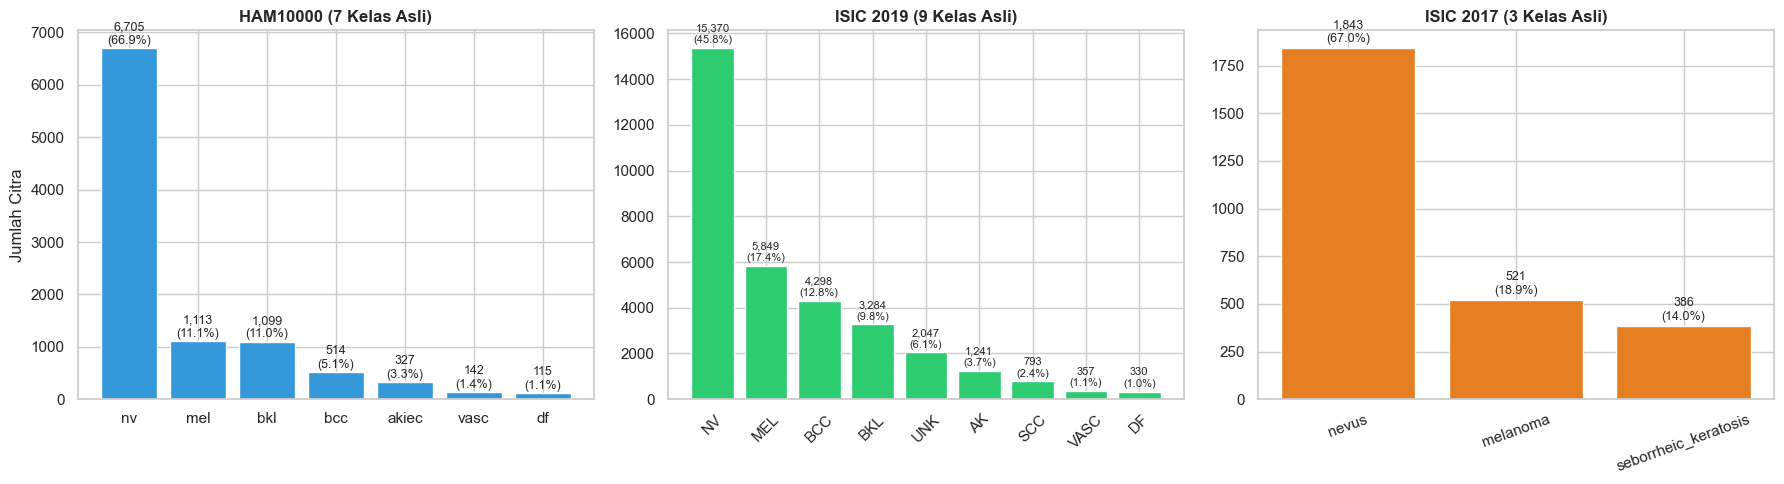

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# HAM10000
sub_ham = df_images[df_images['source'] == 'ham10000']['original_label'].value_counts()
axes[0].bar(sub_ham.index, sub_ham.values, color='#3498db')
axes[0].set_title('HAM10000 (7 Kelas Asli)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Citra')
for i, v in enumerate(sub_ham.values):
    axes[0].text(i, v + 80, f"{v:,}\n({v/len(df_images[df_images['source'] == 'ham10000'])*100:.1f}%)", ha='center', fontsize=9)

# ISIC 2019
sub_19 = df_images[df_images['source'].str.startswith('isic_2019')]['original_label'].value_counts()
axes[1].bar(sub_19.index, sub_19.values, color='#2ecc71')
axes[1].set_title('ISIC 2019 (9 Kelas Asli)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(sub_19.values):
    axes[1].text(i, v + 200, f"{v:,}\n({v/len(df_images[df_images['source'].str.startswith('isic_2019')])*100:.1f}%)", ha='center', fontsize=8)

# ISIC 2017
sub_17 = df_images[df_images['source'].str.startswith('isic_2017')]['original_label'].value_counts()
axes[2].bar(sub_17.index, sub_17.values, color='#e67e22')
axes[2].set_title('ISIC 2017 (3 Kelas Asli)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)
for i, v in enumerate(sub_17.values):
    axes[2].text(i, v + 30, f"{v:,}\n({v/len(df_images[df_images['source'].str.startswith('isic_2017')])*100:.1f}%)", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Langkah 7: Deteksi Gambar Duplikat Lintas-Dataset
Melacak gambar yang muncul di lebih dari satu dataset karena dirilis ulang oleh konsorsium ISIC.

In [7]:
dup_group = df_images.groupby('image_id')['source'].apply(lambda x: sorted(list(set(x)))).reset_index()
dup_group['jumlah_source'] = dup_group['source'].apply(len)
df_dups = dup_group[dup_group['jumlah_source'] > 1].sort_values('jumlah_source', ascending=False).reset_index(drop=True)

print(f"Total gambar unik yang muncul di lebih dari 1 dataset: {len(df_dups):,} gambar")

df_dups_tampil = df_dups.head(8).copy()
df_dups_tampil['Muncul di Dataset'] = df_dups_tampil['source'].apply(lambda l: ', '.join(l))
display(df_dups_tampil[['image_id', 'jumlah_source', 'Muncul di Dataset']])

Total gambar unik yang muncul di lebih dari 1 dataset: 10,735 gambar


,ID Gambar (image_id),Jumlah Dataset,Muncul di Dataset Mana Saja
0,ISIC_0000000,2,"isic_2017_train, isic_2019_train"
1,ISIC_0030736,2,"ham10000, isic_2019_train"
2,ISIC_0030738,2,"ham10000, isic_2019_train"
3,ISIC_0030739,2,"ham10000, isic_2019_train"
4,ISIC_0030740,2,"ham10000, isic_2019_train"
5,ISIC_0030741,2,"ham10000, isic_2019_train"
6,ISIC_0030742,2,"ham10000, isic_2019_train"
7,ISIC_0030743,2,"ham10000, isic_2019_train"


## Langkah 8: Analisis Pasangan Dataset yang Saling Berbagi Gambar
Menghitung irisan gambar antar-dataset untuk mengetahui pasangan data yang saling tumpang tindih.

In [8]:
pair_counter = Counter()
for src_list in df_dups['source']:
    for a, b in combinations(src_list, 2):
        pair_counter[(a, b)] += 1

df_pairs = pd.DataFrame([{'Dataset 1': k[0], 'Dataset 2': k[1], 'Jumlah Gambar Dobel': f"{v:,}"} for k, v in pair_counter.items()])
display(df_pairs)

,Dataset 1,Dataset 2,Jumlah Gambar Dobel
0,isic_2017_train,isic_2019_train,717
1,isic_2017_val,isic_2019_train,2
2,ham10000,isic_2019_train,"10,015"
3,isic_2017_test,isic_2019_train,1


## Langkah 9: Pembersihan Duplikat (Deduplikasi Data)
Menghapus gambar kembar dengan prioritas mempertahankan HAM10000 secara 100% utuh, diikuti ISIC 2019, lalu ISIC 2017.

In [9]:
PRIORITY_ORDER = [
    'ham10000',
    'isic_2019_train',
    'isic_2019_test',
    'isic_2017_train',
    'isic_2017_val',
    'isic_2017_test'
]

priority_map = {src: i for i, src in enumerate(PRIORITY_ORDER)}
df_sorted = df_images.copy()
df_sorted['priority'] = df_sorted['source'].map(priority_map)
df_sorted = df_sorted.sort_values('priority').reset_index(drop=True)

df_clean = df_sorted.drop_duplicates(subset=['image_id'], keep='first').reset_index(drop=True)
df_dropped = df_sorted[df_sorted.duplicated(subset=['image_id'], keep='first')].reset_index(drop=True)

print(f"Total data mentah : {len(df_images):,} citra")
print(f"Duplikat dibuang  : {len(df_dropped):,} citra")
print(f"Total data bersih : {len(df_clean):,} citra")

Total data mentah : 46,334 citra
Duplikat dibuang  : 10,735 citra
Total data bersih : 35,599 citra


## Langkah 10: Evaluasi Data Sebelum vs Sesudah Deduplikasi
Menampilkan tabel perbandingan jumlah citra sebelum dan sesudah pembersihan, rincian dataset asal duplikasi, beserta persentase data yang dipertahankan.

In [10]:
clean_keeper_map = dict(zip(df_clean['image_id'], df_clean['source']))
df_dropped['kept_by'] = df_dropped['image_id'].map(clean_keeper_map)

before_counts = df_images['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows_ba = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    pct = (a / b * 100) if b > 0 else 0
    sub = df_dropped[df_dropped['source'] == src]
    if d == 0:
        dup_target = "- (Data primer utuh)"
    else:
        target_counts = sub['kept_by'].value_counts().to_dict()
        dup_target = ", ".join([f"{k} ({v:,})" for k, v in target_counts.items()])
    rows_ba.append({
        'Source Dataset': src,
        'Before (Mentah)': f"{b:,}",
        'Duplikat Dibuang': f"{d:,}",
        'Duplikat dengan Dataset Mana': dup_target,
        'After (Bersih)': f"{a:,}",
        'Persentase Bertahan': f"{pct:.1f}%"
    })

df_ba = pd.DataFrame(rows_ba)
display(df_ba)

,Source Dataset,Before (Mentah),Duplikat Dibuang,Duplikat dengan Dataset Mana,After (Bersih),Persentase Bertahan
0,ham10000,"10,015",0,- (Data primer utuh),"10,015",100.0%
1,isic_2019_train,"25,331","10,015","ham10000 (10,015)","15,316",60.5%
2,isic_2019_test,"8,238",0,- (Data primer utuh),"8,238",100.0%
3,isic_2017_train,"2,000",717,isic_2019_train (717),"1,283",64.1%
4,isic_2017_val,150,2,isic_2019_train (2),148,98.7%
5,isic_2017_test,600,1,isic_2019_train (1),599,99.8%


## Langkah 11: Visualisasi Data Sebelum vs Sesudah Deduplikasi
Grafik batang perbandingan jumlah citra mentah (Before) dengan citra bersih (After) pada masing-masing sumber dataset.

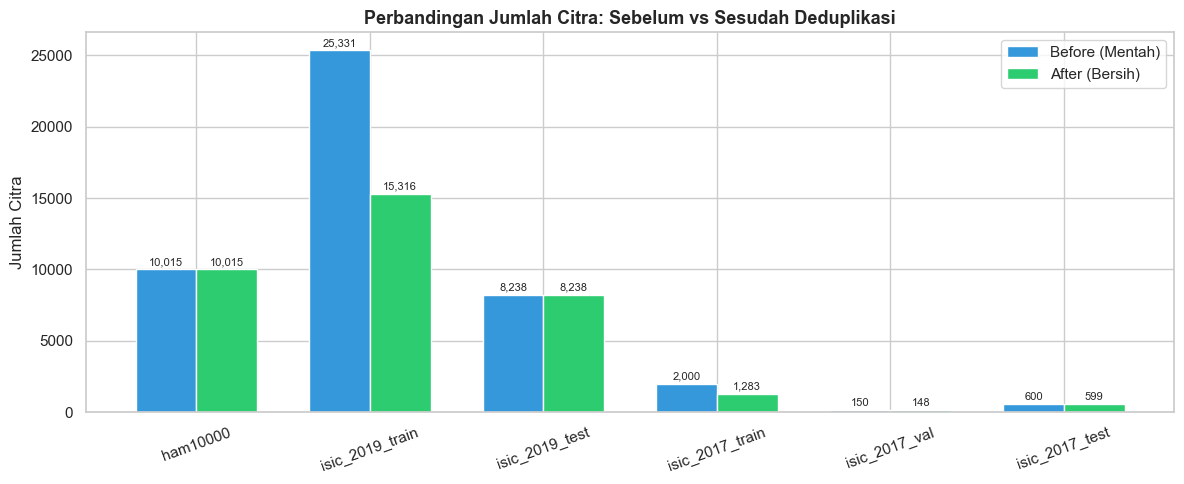

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_ba))
w = 0.35

b_vals = [int(r['Before (Mentah)'].replace(',', '')) for r in rows_ba]
a_vals = [int(r['After (Bersih)'].replace(',', '')) for r in rows_ba]

bars1 = ax.bar(x - w/2, b_vals, w, label='Before (Mentah)', color='#3498db')
bars2 = ax.bar(x + w/2, a_vals, w, label='After (Bersih)', color='#2ecc71')

ax.set_title('Perbandingan Jumlah Citra: Sebelum vs Sesudah Deduplikasi', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([r['Source Dataset'] for r in rows_ba], rotation=20)
ax.set_ylabel('Jumlah Citra')
ax.legend()

for bar in bars1:
    h = bar.get_height()
    ax.annotate(f'{h:,}', xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

for bar in bars2:
    h = bar.get_height()
    ax.annotate(f'{h:,}', xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## Langkah 12: Ekspor Metadata Dataset Bersih
Menyimpan metadata 35.599 citra unik hasil deduplikasi ke file CSV sebagai bahan dasar tahap pemetaan biner.

In [12]:
output_clean_path = os.path.join(ROOT, 'dataset_clean_3dataset.csv')
cols_to_save = ['image_id', 'source', 'original_label', 'filepath']
df_clean[cols_to_save].to_csv(output_clean_path, index=False)

print(f"File metadata bersih tersimpan di: {output_clean_path}")
print(f"Total baris data bersih: {len(df_clean):,} citra")
display(df_clean[cols_to_save].head(10))

File metadata bersih tersimpan di: C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_clean_3dataset.csv
Total baris data bersih: 35,599 citra


,image_id,source,original_label,filepath
0,ISIC_0024306,ham10000,nv,C:\Users\ARII\Downloads\Data Understanding Isi...
1,ISIC_0030979,ham10000,nv,C:\Users\ARII\Downloads\Data Understanding Isi...
2,ISIC_0030980,ham10000,nv,C:\Users\ARII\Downloads\Data Understanding Isi...
3,ISIC_0030981,ham10000,nv,C:\Users\ARII\Downloads\Data Understanding Isi...
4,ISIC_0030982,ham10000,nv,C:\Users\ARII\Downloads\Data Understanding Isi...
5,ISIC_0030983,ham10000,nv,C:\Users\ARII\Downloads\Data Understanding Isi...
6,ISIC_0030984,ham10000,nv,C:\Users\ARII\Downloads\Data Understanding Isi...
7,ISIC_0030985,ham10000,nv,C:\Users\ARII\Downloads\Data Understanding Isi...
8,ISIC_0030986,ham10000,akiec,C:\Users\ARII\Downloads\Data Understanding Isi...
9,ISIC_0030987,ham10000,nv,C:\Users\ARII\Downloads\Data Understanding Isi...
